In [36]:
# To check that dataset ('AEP_hourly.csv') has been uploaded.
# Source: https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption

import os
os.listdir('/content')

['.config', 'AEP_hourly.csv', 'sample_data']

In [37]:
# ============================================================
# ****** SETUP: IMPORTS + CONFIG ******
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima import auto_arima

from sklearn.metrics import mean_absolute_error

forecast_horizon = 168

In [38]:
# ============================================================
# ****** STEP 1: DATASET OVERVIEW ******
# ============================================================
# Load dataset, inspect structure, check missing values,
# and prepare datetime index.

df = pd.read_csv("AEP_hourly.csv")

df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime")
df.set_index("Datetime", inplace=True)

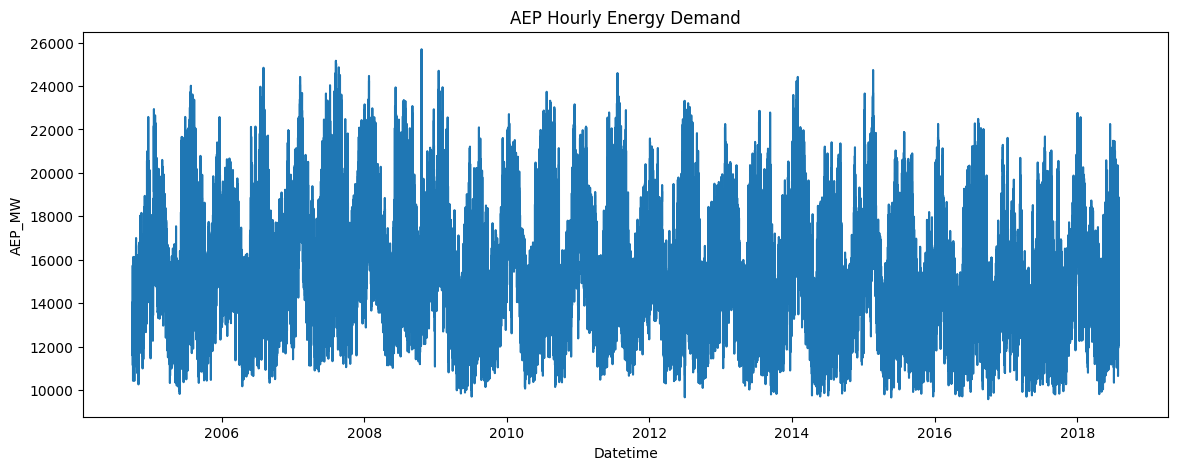

In [39]:
# ============================================================
# ****** STEP 2: TIME-SERIES VISUALIZATION ******
# ============================================================
# Plot electricity demand over time.

plt.figure(figsize=(14,5))
plt.plot(df["AEP_MW"])
plt.title("AEP Hourly Energy Demand")
plt.xlabel("Datetime")
plt.ylabel("AEP_MW")
plt.show()

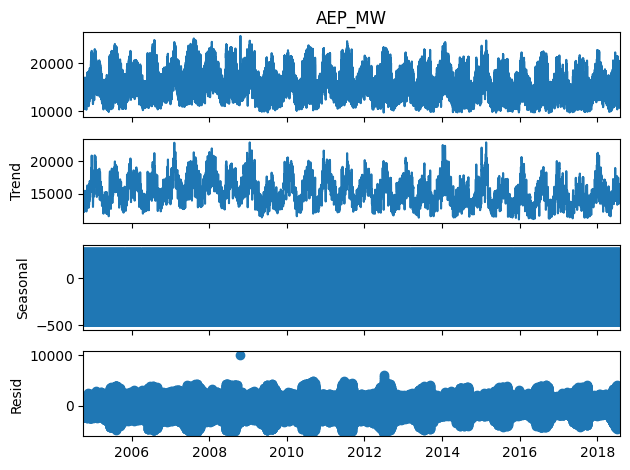

In [40]:
# ============================================================
# ****** STEP 3: TREND AND SEASONALITY DECOMPOSITION ******
# ============================================================
# Decompose the series into trend, seasonal, and residual parts.

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df["AEP_MW"],
    model="additive",
    period=24
)

decomposition.plot()
plt.show()

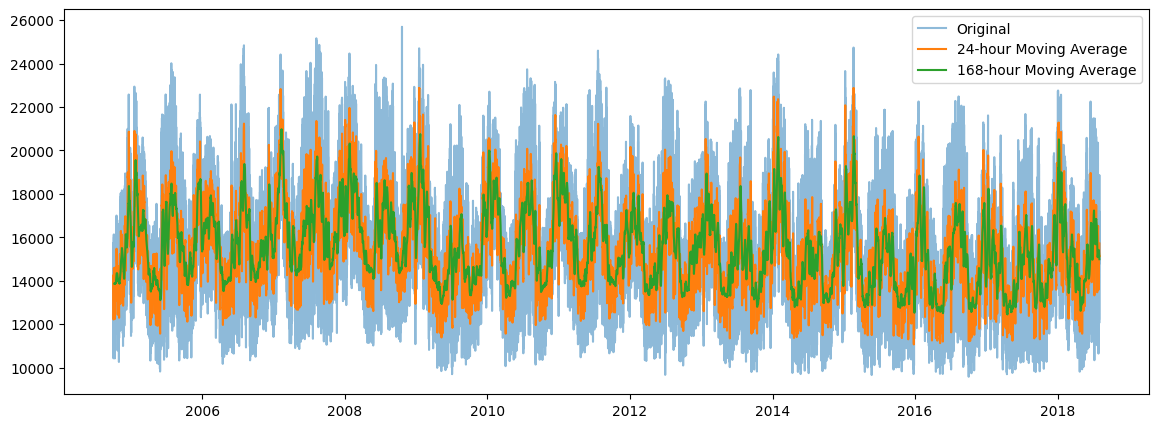

In [41]:
# ============================================================
# ****** STEP 4: MOVING AVERAGES ******
# ============================================================
# Calculate rolling averages to smooth short-term fluctuations.

df["MA_24"] = df["AEP_MW"].rolling(window=24).mean()
df["MA_168"] = df["AEP_MW"].rolling(window=168).mean()

plt.figure(figsize=(14,5))
plt.plot(df["AEP_MW"], label="Original", alpha=0.5)
plt.plot(df["MA_24"], label="24-hour Moving Average")
plt.plot(df["MA_168"], label="168-hour Moving Average")
plt.legend()
plt.show()

In [42]:
# ============================================================
# ****** STEP 5: TRAIN-TEST SPLIT ******
# ============================================================
# Reserve the last 168 hours for testing and forecasting.

forecast_horizon = 168

train = df["AEP_MW"][:-forecast_horizon]
test = df["AEP_MW"][-forecast_horizon:]

print("Training samples:", len(train))
print("Testing samples:", len(test))

Training samples: 121105
Testing samples: 168


In [44]:
# ============================================================
# ****** STEP 6: ARIMA MODEL FITTING ******
# ============================================================

train_subset = train[-5000:]

model = auto_arima(
    train_subset,
    seasonal=False,
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    max_p=3,
    max_q=3
)

print(model.order)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=69454.763, Time=13.57 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=76767.170, Time=0.21 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=70858.873, Time=0.66 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=72669.516, Time=2.31 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=76765.174, Time=0.09 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=70101.608, Time=3.35 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=69663.209, Time=4.92 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=69467.205, Time=12.65 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=69448.671, Time=10.67 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=70096.824, Time=6.34 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=69173.674, Time=14.62 sec
 ARIMA(3,1,3)(0,0,0)[0]             : AIC=69139.721, Time=5.96 sec
 ARIMA(2,1,3)(0,0,0)[0]             : AIC=69446.692, Time=3.58 sec
 ARIMA(3,1,2)(0,0,0)[0]             : AIC=69465.197, Time=6.92 sec
 ARIMA(2,1,2)(0

In [45]:
from statsmodels.tsa.arima.model import ARIMA

model_fit = ARIMA(train, order=model.order).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [47]:
# ============================================================
# ****** STEP 7: FORECASTING ******
# ============================================================

forecast = model_fit.forecast(steps=168)
forecast.head()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,predicted_mean
121105,14045.793242
121106,13299.346849
121107,12870.119383
121108,12744.573249
121109,12902.492937


In [48]:
# ============================================================
# ****** STEP 8: PERFORMANCE EVALUATION ******
# ============================================================
# Evaluate forecasting accuracy using MAE and RMSE.

from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae = mean_absolute_error(test, forecast)
rmse = root_mean_squared_error(test, forecast)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

MAE: 1829.66
RMSE: 2293.4


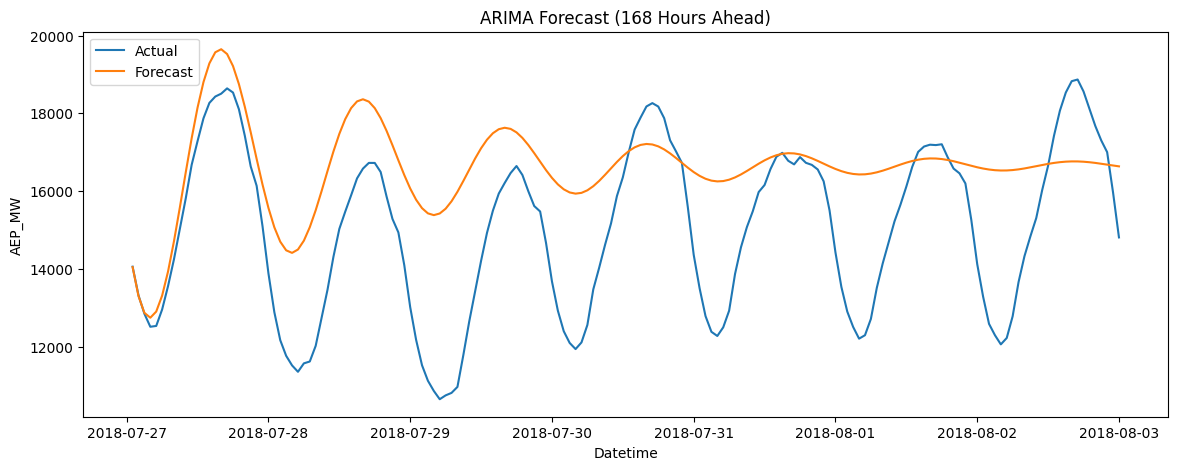

In [49]:
# ============================================================
# ****** STEP 9: FORECAST VISUALIZATION ******
# ============================================================
# Compare actual and predicted values.

plt.figure(figsize=(14,5))

plt.plot(test.index, test,
         label="Actual")

plt.plot(test.index, forecast,
         label="Forecast")

plt.title("ARIMA Forecast (168 Hours Ahead)")
plt.xlabel("Datetime")
plt.ylabel("AEP_MW")

plt.legend()
plt.show()